In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

df = pd.read_csv(os.path.join('..', 'new_data.csv'), index_col=0)
df

,age,education,sex,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
id,,,,,,,,,,,,,,,
1,36,4.0,1,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,46,1.0,0,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,50,1.0,1,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,64,1.0,0,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0
5,61,3.0,0,0.0,0.0,0,1,0,272.0,182.0,121.0,32.80,85.0,65.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3384,61,1.0,0,0.0,0.0,0,1,0,217.0,182.0,86.0,26.98,105.0,113.0,0
3385,60,1.0,0,0.0,0.0,0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,46,1.0,0,0.0,0.0,0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0


In [3]:
df['TenYearCHD'].value_counts(normalize=True)

TenYearCHD
0    0.848309
1    0.151691
Name: proportion, dtype: float64

NOTE: I will not include oversampling with SMOTE in this notebook and will instead rely on `class_weight='balanced'` parameter that is set during model initialization call to handle the class imbalance.

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train.shape

(2487, 14)

In [5]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(TenYearCHD
 0    0.848412
 1    0.151588
 Name: proportion, dtype: float64,
 TenYearCHD
 0    0.847727
 1    0.152273
 Name: proportion, dtype: float64)

### Feature Scaling

In [6]:
X_train.dtypes.to_dict()

{'age': dtype('int64'),
 'education': dtype('float64'),
 'sex': dtype('int64'),
 'cigsPerDay': dtype('float64'),
 'BPMeds': dtype('float64'),
 'prevalentStroke': dtype('int64'),
 'prevalentHyp': dtype('int64'),
 'diabetes': dtype('int64'),
 'totChol': dtype('float64'),
 'sysBP': dtype('float64'),
 'diaBP': dtype('float64'),
 'BMI': dtype('float64'),
 'heartRate': dtype('float64'),
 'glucose': dtype('float64')}

In [7]:
from sklearn.preprocessing import StandardScaler

numerics = [
    'age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose'
]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()
X_train_scaled[numerics] = scaler.fit_transform(X_train[numerics])
X_test_scaled[numerics] = scaler.transform(X_test[numerics])

In [8]:
pd.DataFrame(X_test_scaled, columns=X_test.columns).sample(10)

,age,education,sex,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
id,,,,,,,,,,,,,,
121,1.687797,4.0,1,-0.761486,0.0,0,0,0,0.791607,-0.440430,-0.779032,-0.850601,-0.076145,0.078775
3269,-1.220706,1.0,0,0.491756,0.0,0,0,0,0.392931,0.414873,0.217045,-0.222622,2.014989,1.046840
2548,1.222436,3.0,1,-0.761486,0.0,0,0,0,-0.293677,0.482396,-0.447006,0.078032,-0.912599,-0.042234
744,0.757076,1.0,1,-0.761486,0.0,0,0,0,0.127148,-0.192843,-0.654522,0.453849,0.342082,0.280455
1305,-0.871685,3.0,0,-0.761486,0.0,0,0,0,0.725161,-0.305383,0.258548,-0.443263,0.342082,-0.203578
3255,0.059035,1.0,0,0.909503,0.0,0,0,0,-0.360122,-0.935606,-1.152560,-0.421442,0.342082,-0.122906
2816,-0.871685,4.0,1,-0.761486,0.0,0,0,0,-1.024582,-0.665510,-0.239490,-0.200800,-1.163535,-0.768283
2353,1.338776,3.0,0,-0.761486,0.0,0,0,0,-0.050041,-1.385765,-0.696025,-1.597386,-0.745308,0.038438
2448,1.106096,1.0,0,-0.761486,0.0,0,1,0,0.503674,1.337699,1.835669,-0.343854,-0.076145,-0.405258


### Model Training and Evaluations

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm, columns=['Predicted: 0', 'Predicted: 1'], index=['Actual: 0', 'Actual: 1']
    )
    plt.figure(figsize=(7, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

def plot_roc(clf, X_test, y_test):
    probs = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    fpr, tpr, _ = roc_curve(y_test, probs)
    
    plt.figure(figsize=(8, 5))
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (AUC = {round(auc, 3)})')
    plt.tight_layout()
    plt.show()
    return auc

### Logistic Regression

In [11]:
lr_params = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': ['balanced', None],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42), param_grid=lr_params, cv=5
)
lr_grid.fit(X_train_scaled, y_train)
print("Best params:", lr_grid.best_params_)

Best params: {'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}


In [12]:
lr_pred = lr_grid.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, lr_pred)
logistic_f1 = f1_score(y_test, lr_pred)
print(f"Accuracy: {round(log_accuracy * 100, 2)}%")
print(f"F1 Score: {round(logistic_f1 * 100, 2)}%")
print()
print(classification_report(y_test, lr_pred))

Accuracy: 85.23%
F1 Score: 10.96%

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       373
           1       0.67      0.06      0.11        67

    accuracy                           0.85       440
   macro avg       0.76      0.53      0.51       440
weighted avg       0.83      0.85      0.80       440



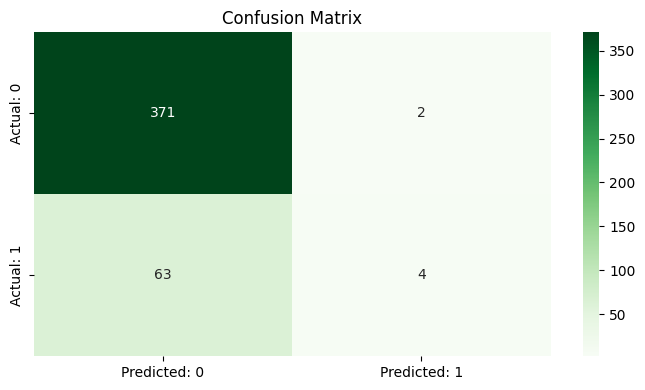

In [13]:
plot_confusion_matrix(y_pred=lr_pred, y_true=y_test)

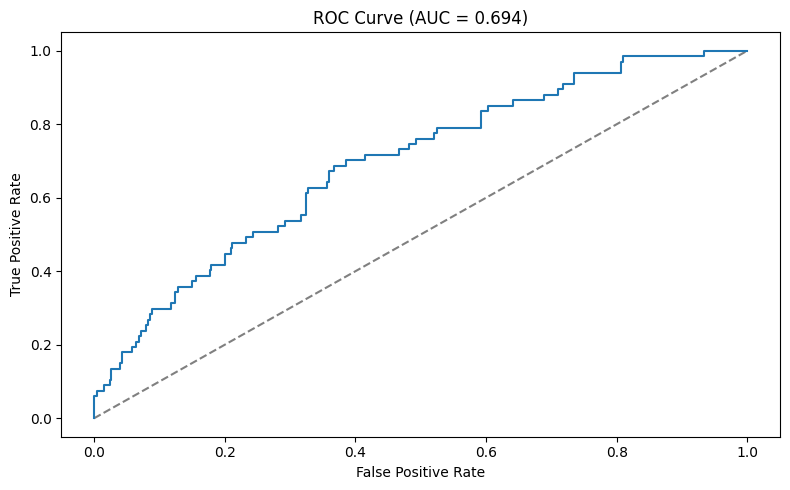

np.float64(0.6940898723540474)

In [14]:
plot_roc(lr_grid, X_test_scaled, y_test)

In [15]:
lr_model = LogisticRegression(
    penalty='l2', C=0.01, class_weight='balanced', random_state=42
)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(C=0.01, class_weight='balanced', random_state=42)

In [16]:
lr_pred = lr_model.predict(X_test_scaled)
log_accuracy = accuracy_score(y_test, lr_pred)
logistic_f1 = f1_score(y_test, lr_pred)
print(f"Accuracy: {round(log_accuracy * 100, 2)}%")
print(f"F1 Score: {round(logistic_f1 * 100, 2)}%")
print()
print(classification_report(y_test, lr_pred))

Accuracy: 65.68%
F1 Score: 35.19%

              precision    recall  f1-score   support

           0       0.91      0.66      0.77       373
           1       0.25      0.61      0.35        67

    accuracy                           0.66       440
   macro avg       0.58      0.64      0.56       440
weighted avg       0.80      0.66      0.70       440



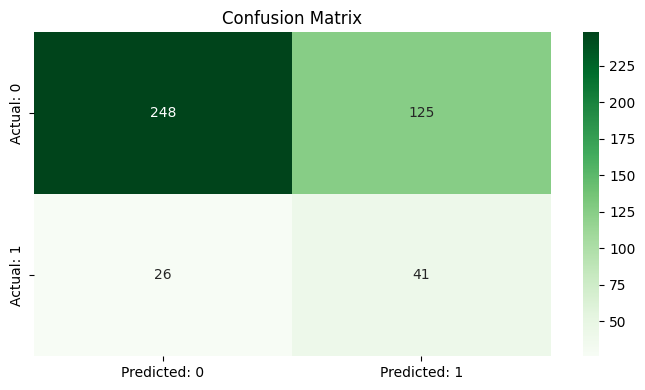

In [17]:
plot_confusion_matrix(y_pred=lr_pred, y_true=y_test)

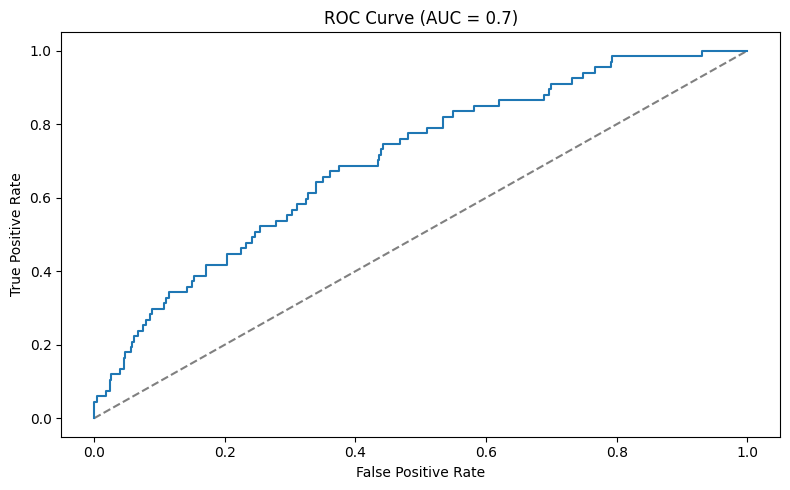

np.float64(0.7004921771837862)

In [18]:
plot_roc(lr_model, X_test_scaled, y_test)

### K-Nearest Neighbors

In [19]:
params= {'n_neighbors': np.arange(1, 16)}
knn_grid = GridSearchCV(KNeighborsClassifier(), scoring='accuracy', param_grid=params, cv=10)
knn_grid.fit(X_train_scaled, y_train)
print("Best params:", knn_grid.best_params_)

Best params: {'n_neighbors': np.int64(12)}


In [20]:
from sklearn.model_selection import cross_val_score

knn_f1_score = cross_val_score(
    estimator=KNeighborsClassifier(**knn_grid.best_params_),
    X=X_train_scaled,
    y=y_train,
    cv=5,
    scoring='f1_macro'
)

knn_f1_score.mean()

np.float64(0.4953643831629906)

In [21]:
knn_model = KNeighborsClassifier(n_neighbors=2)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)
print(f"Accuracy: {round(knn_accuracy * 100, 2)}%")
print(f"F1 Score: {round(knn_f1 * 100, 2)}%")
print()
print(classification_report(y_test, knn_pred))

Accuracy: 84.32%
F1 Score: 10.39%

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       373
           1       0.40      0.06      0.10        67

    accuracy                           0.84       440
   macro avg       0.63      0.52      0.51       440
weighted avg       0.78      0.84      0.79       440



### Decision Tree

In [22]:
tree_params = {
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': list(range(2, 15)),
    'min_samples_leaf': list(range(1, 10))
}

tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid=tree_params, cv=5, scoring='f1_macro'
)
tree_grid.fit(X_train_scaled, y_train)
print("Best params:", tree_grid.best_params_)

Best params: {'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2}


In [23]:
tree_pred = tree_grid.predict(X_test_scaled)

tree_accuracy = accuracy_score(y_test, tree_pred)
tree_f1 = f1_score(y_test, tree_pred)
print(f"Accuracy: {round(tree_accuracy * 100, 2)}%")
print(f"F1 Score: {round(tree_f1 * 100, 2)}%")
print()
print(classification_report(y_test, tree_pred))

Accuracy: 73.18%
F1 Score: 21.33%

              precision    recall  f1-score   support

           0       0.86      0.82      0.84       373
           1       0.19      0.24      0.21        67

    accuracy                           0.73       440
   macro avg       0.52      0.53      0.53       440
weighted avg       0.76      0.73      0.74       440



Accuracy: 73.18%
F1 Score: 21.33%

              precision    recall  f1-score   support

           0       0.86      0.82      0.84       373
           1       0.19      0.24      0.21        67

    accuracy                           0.73       440
   macro avg       0.52      0.53      0.53       440
weighted avg       0.76      0.73      0.74       440



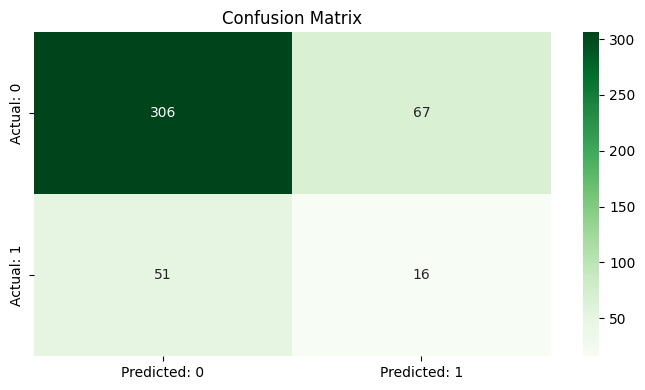

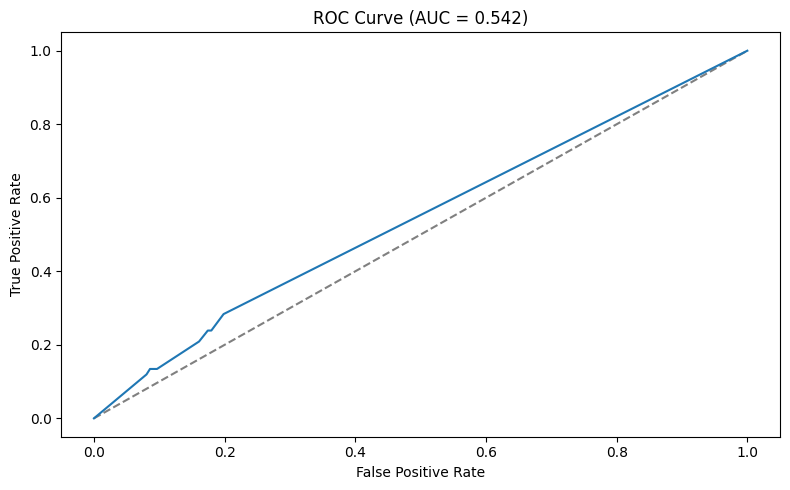

np.float64(0.5416149813933016)

In [24]:
tree_model = DecisionTreeClassifier(
    random_state=42, class_weight='balanced', **tree_grid.best_params_
)
tree_model.fit(X=X_train_scaled, y=y_train)

tree_pred = tree_model.predict(X_test_scaled)
tree_accuracy = accuracy_score(y_test, tree_pred)
tree_f1 = f1_score(y_test, tree_pred)
print(f"Accuracy: {round(tree_accuracy * 100, 2)}%")
print(f"F1 Score: {round(tree_f1 * 100, 2)}%")
print()
print(classification_report(y_test, tree_pred))
plot_confusion_matrix(y_pred=tree_pred, y_true=y_test)
plot_roc(tree_model, X_test_scaled, y_test)

### Support Vector Classifier

In [25]:
svc_params = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1, 1]
}

svc_grid = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced'),
    param_grid=svc_params, cv=5, scoring='f1_macro',
    n_jobs=-1
)
svc_grid.fit(X_train_scaled, y_train)
print("Best params:", svc_grid.best_params_)

Best params: {'C': 0.1, 'gamma': 0.001}


In [26]:
svc_pred = svc_grid.predict(X_test_scaled)

svc_accuracy = accuracy_score(y_test, svc_pred)
svc_f1 = f1_score(y_test, svc_pred)
print(f"Accuracy: {round(svc_accuracy * 100, 2)}%")
print(f"F1 Score: {round(svc_f1 * 100, 2)}%")
print()
print(classification_report(y_test, svc_pred))

Accuracy: 78.18%
F1 Score: 34.25%

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       373
           1       0.32      0.37      0.34        67

    accuracy                           0.78       440
   macro avg       0.60      0.61      0.61       440
weighted avg       0.80      0.78      0.79       440



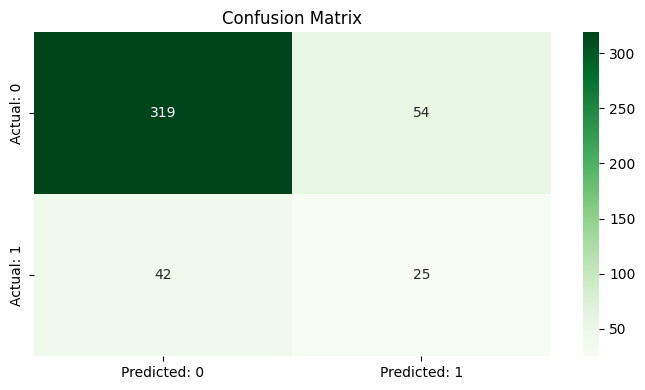

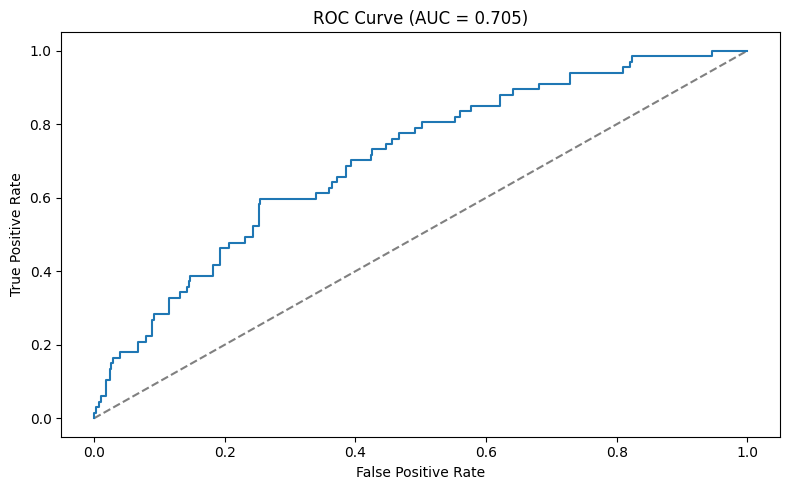

np.float64(0.7050138049697892)

In [27]:
plot_confusion_matrix(y_pred=svc_pred, y_true=y_test)
plot_roc(svc_grid, X_test_scaled, y_test)

### Random Forest Classifier

In [28]:
rf_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=rf_params, cv=5, scoring='f1_macro',
    n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)
print("Best params:", rf_grid.best_params_)

Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 150}


Accuracy: 80.0%
F1 Score: 24.14%

              precision    recall  f1-score   support

           0       0.86      0.91      0.88       373
           1       0.29      0.21      0.24        67

    accuracy                           0.80       440
   macro avg       0.58      0.56      0.56       440
weighted avg       0.78      0.80      0.79       440



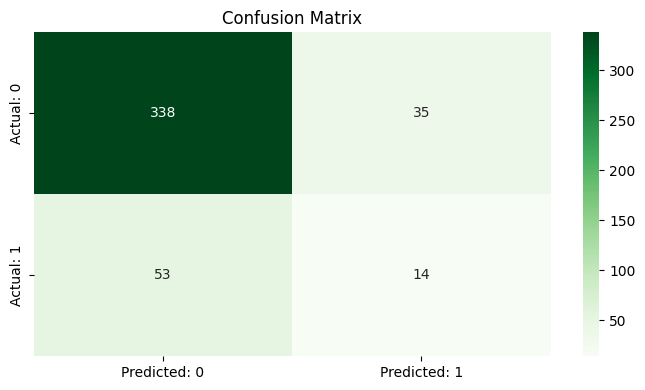

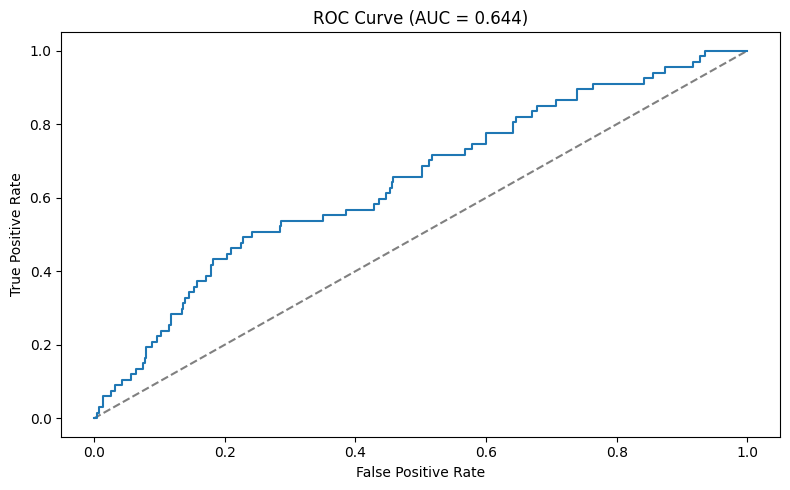

np.float64(0.644031851466528)

In [29]:
rf_pred = rf_grid.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
print(f"Accuracy: {round(rf_accuracy * 100, 2)}%")
print(f"F1 Score: {round(rf_f1 * 100, 2)}%")
print()
print(classification_report(y_test, rf_pred))

plot_confusion_matrix(y_pred=rf_pred, y_true=y_test)
plot_roc(rf_grid, X_test_scaled, y_test)

In [30]:
rf_feature_importance = pd.DataFrame(
    {
        'Feature': X_train.columns,
        'Importance': rf_grid.best_estimator_.feature_importances_
    }
)
rf_grid.best_estimator_.feature_importances_

array([0.18810014, 0.02933628, 0.02725195, 0.0628219 , 0.00590715,
       0.00053358, 0.02446421, 0.00440292, 0.11290049, 0.15290391,
       0.10256133, 0.10403232, 0.08011792, 0.10466591])

In [31]:
rf_feature_importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
0,age,0.188100
9,sysBP,0.152904
8,totChol,0.112900
13,glucose,0.104666
11,BMI,0.104032
10,diaBP,0.102561
12,heartRate,0.080118
3,cigsPerDay,0.062822
1,education,0.029336
2,sex,0.027252


<Axes: ylabel='Feature'>

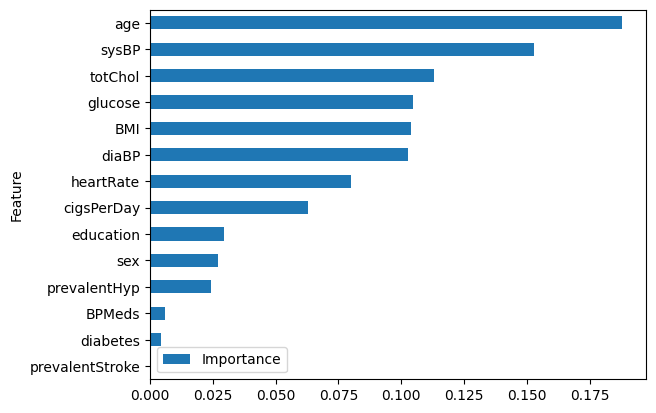

In [32]:
rf_feature_importance.index = rf_feature_importance['Feature']
df_rf_features = rf_feature_importance.drop('Feature', axis=1).sort_values(
    by='Importance', ascending=True
)
df_rf_features.plot(kind='barh')

In [33]:
comparison = pd.DataFrame({
    'Logistic Regression':   {'Accuracy': log_accuracy, 'F1 Score': logistic_f1},
    'K-Nearest Neighbors':   {'Accuracy': knn_accuracy, 'F1 Score': knn_f1},
    'Decision Tree':         {'Accuracy': tree_accuracy, 'F1 Score': tree_f1},
    'Support Vector Machine':{'Accuracy': svc_accuracy, 'F1 Score': svc_f1},
    'Random Forest':         {'Accuracy': rf_accuracy, 'F1 Score': rf_f1},
}).T.round(4)

comparison

,Accuracy,F1 Score
Logistic Regression,0.6568,0.3519
K-Nearest Neighbors,0.8432,0.1039
Decision Tree,0.7318,0.2133
Support Vector Machine,0.7818,0.3425
Random Forest,0.8000,0.2414


All models performed relatively poorly in terms of F1 score, albeit accuracy scores reaching 84%, and this is most likely due to the class imbalance noted earlier, which was not properly handled with SMOTE, and is not adequetly addressed with `class_weight='balanced` loss function penalty adjustment. Class imbalance handling, as well as feature selection and preprocessing need fresh look to potentially improve model performance. But before that let's analyze Xgboost with a few configurations and training approaches...

### XGBoost Classifier

In [34]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
scale_pos_weight

np.float64(5.596816976127321)

In [35]:
xgboost_model = XGBClassifier(
    random_state=42, use_label_encoder=False, eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
)

xgboost_model.fit(X_train_scaled, y_train)
xgboost_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

Accuracy: 79.09%
F1 Score: 22.03%

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       373
           1       0.25      0.19      0.22        67

    accuracy                           0.79       440
   macro avg       0.56      0.55      0.55       440
weighted avg       0.77      0.79      0.78       440



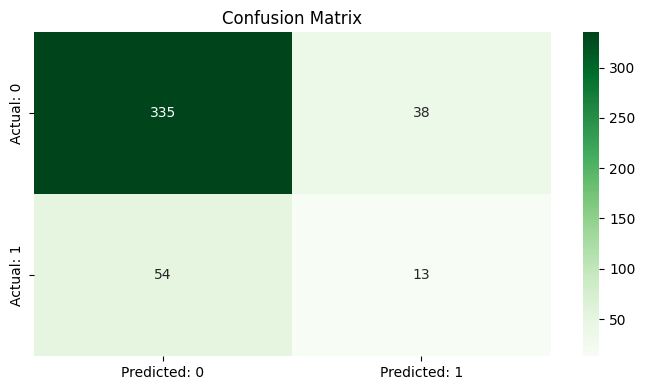

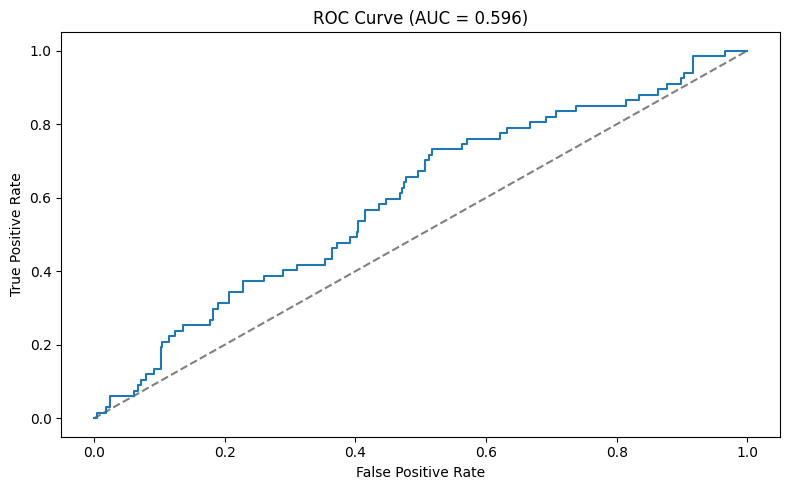

np.float64(0.5955343923812572)

In [36]:
xgboost_pred = xgboost_model.predict(X_test_scaled)

xgboost_accuracy = accuracy_score(y_test, xgboost_pred)
xgboost_f1 = f1_score(y_test, xgboost_pred)
print(f"Accuracy: {round(xgboost_accuracy * 100, 2)}%")
print(f"F1 Score: {round(xgboost_f1 * 100, 2)}%")
print()
print(classification_report(y_test, xgboost_pred))

plot_confusion_matrix(y_pred=xgboost_pred, y_true=y_test)
plot_roc(xgboost_model, X_test_scaled, y_test)

In [37]:
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'gamma': [0, 0.1, 0.25],
    'scale_pos_weight': [1, 3, 5, 10]
}

xgboost_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

xgboost_grid.fit(
    X_train_scaled,
    y_train
)

print(xgboost_grid.best_score_)
print(xgboost_grid.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
0.5976644974525722
{'gamma': 0, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': 5}


Accuracy: 75.23%
F1 Score: 32.3%

              precision    recall  f1-score   support

           0       0.88      0.82      0.85       373
           1       0.28      0.39      0.32        67

    accuracy                           0.75       440
   macro avg       0.58      0.60      0.59       440
weighted avg       0.79      0.75      0.77       440



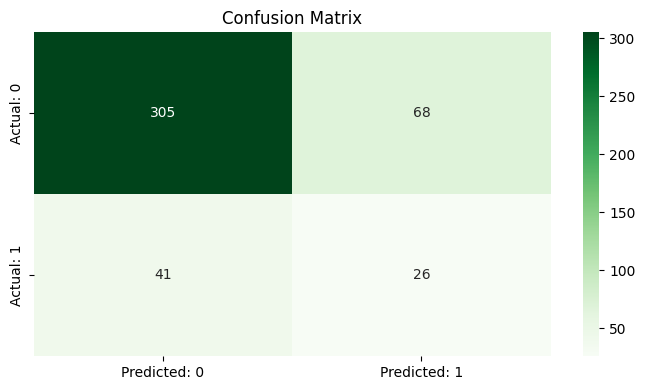

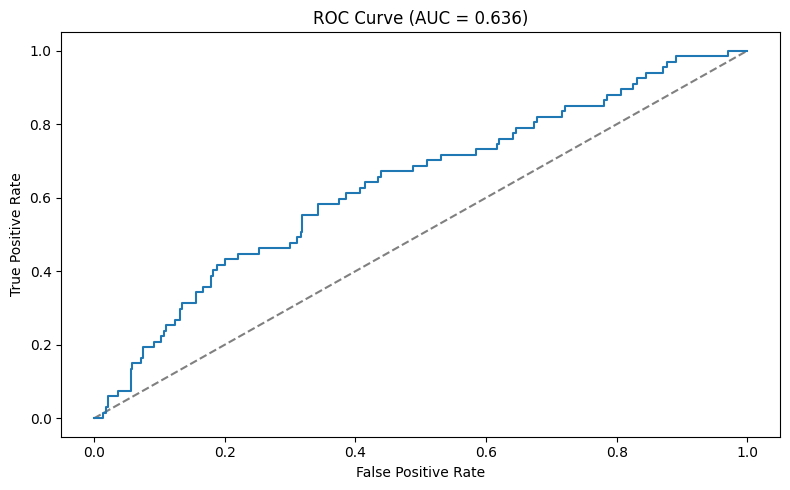

np.float64(0.6363490856708415)

In [38]:
xgboost_pred = xgboost_grid.best_estimator_.predict(X_test_scaled)

xgboost_accuracy = accuracy_score(y_test, xgboost_pred)
xgboost_f1 = f1_score(y_test, xgboost_pred)
print(f"Accuracy: {round(xgboost_accuracy * 100, 2)}%")
print(f"F1 Score: {round(xgboost_f1 * 100, 2)}%")
print()
print(classification_report(y_test, xgboost_pred))

plot_confusion_matrix(y_pred=xgboost_pred, y_true=y_test)
plot_roc(xgboost_grid.best_estimator_, X_test_scaled, y_test)

**Observations:**

Despite extensive hyperparameter tuning of the XGBoost classifier and adjustments for class imbalance (e.g. loss function penalty adjustment through `class_weight` parameter), the F1 score remains relatively low at approximately 33%, while accuracy reaches around 80%. This discrepancy suggests that the model may be biased toward correctly predicting the majority class (negative cases), while struggling to capture the minority class (positive cases).

We could probably try to further improve the data preprocessing, feature engineering, hyperparameter fine-tuning, and etc. but again this might introduce methodological error of overfitting the model to the specific dataset through an overly complex post-hoc workflow; ultimately the issue could be due to this particular dataset's inherent suitablity for the predictive modeling problem at hand.

P.S.\
After reviewing a few notebooks on this particular problem and dataset, I noticed: 1. I had been working with a wrong version of the dataset (Framingham study dataset has 4300+ rows whereas this dataset has about 3300 rows), and more importantly 2. a couple of the notebooks that had reported consistently high accuracy and f1 scores had methodological errors, such as improper handling of class imbalance (e.g. applying SMOTE oversampling before train-test splitting, which causes data leakage and obviously inflates the model performance scores)...

In [39]:
comparison = pd.DataFrame({
    'Logistic Regression': {'Accuracy': log_accuracy, 'F1 Score': logistic_f1},
    'K-Nearest Neighbors': {'Accuracy': knn_accuracy, 'F1 Score': knn_f1},
    'Decision Tree': {'Accuracy': tree_accuracy, 'F1 Score': tree_f1},
    'Support Vector Machine': {'Accuracy': svc_accuracy, 'F1 Score': svc_f1},
    'Random Forest': {'Accuracy': rf_accuracy, 'F1 Score': rf_f1},
    'XGBoost': {'Accuracy': xgboost_accuracy, 'F1 Score': xgboost_f1},
}).T.round(4)

comparison

,Accuracy,F1 Score
Logistic Regression,0.6568,0.3519
K-Nearest Neighbors,0.8432,0.1039
Decision Tree,0.7318,0.2133
Support Vector Machine,0.7818,0.3425
Random Forest,0.8000,0.2414
XGBoost,0.7523,0.3230


<Axes: >

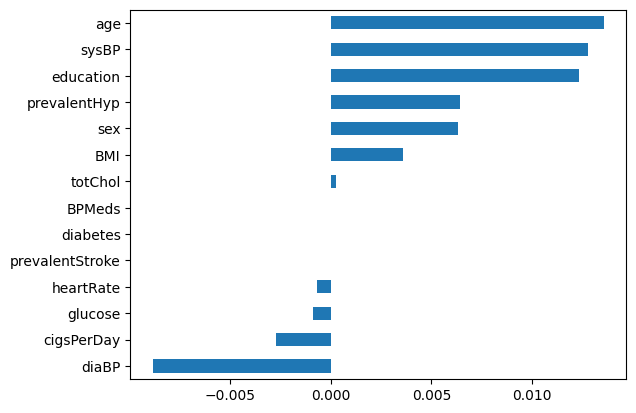

In [40]:
from sklearn.inspection import permutation_importance

result = permutation_importance(svc_grid.best_estimator_, X_test_scaled, y_test, scoring='f1_macro')
importances = result.importances_mean
feature_importance = pd.Series(importances, index=X_test.columns)
feature_importance.sort_values(ascending=True).plot(kind='barh')

This is actually quite interesting, and next steps should definitely address the `heartRate` and `sex` features

In [41]:
auc_values = []

for model in [
    lr_grid,
    knn_grid,
    tree_grid,
    svc_grid,
    rf_grid,
    xgboost_grid
]:
    y_pred = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_true=y_test, y_score=y_pred)
    auc_values.append(auc)

comparison['AUC'] = auc_values
comparison

,Accuracy,F1 Score,AUC
Logistic Regression,0.6568,0.3519,0.694090
K-Nearest Neighbors,0.8432,0.1039,0.641771
Decision Tree,0.7318,0.2133,0.541615
Support Vector Machine,0.7818,0.3425,0.705014
Random Forest,0.8000,0.2414,0.644032
XGBoost,0.7523,0.3230,0.636349


### Final Remarks
Among the analyzed models, Support Vector Machine seems to be the top performing model, and as discussed thoroughly, the issue of low F1 scores despite high accuracy values, is likely due to class imbalance (the models may be biased toward correctly predicting the majority class (negative cases), while struggling to capture the minority class (positive cases)).